In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt
import pyomo.environ as pe

import visualizations as vis

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-built graph. In this case the aggregated California example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [2]:
graph = good.graph.graph_from_json('Examples/California.json')

graph.nodes

NodeView(('WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE', 'WECC_IID', 'WECC_SCE'))

First we will run the grid with custom policies

In [39]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

policies = good.utilities.read_json('Examples/policies.json')

In [40]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 0.16134190559387207
Variables Built: 0.0836479663848877
Constraints Built: 1.4785642623901367
Objective Built: 0.08541250228881836


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 51328, continuous_variables = 24228, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 24228), overall = Bunch(binary_variables = 0, constraints = 51328, continuous_variables = 24228, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 24228), warning = Bunch(unassociated_disjuncts = 0))

In [41]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 1.7465131282806396
Results Collected: 0.7257387638092041
Objective Value: 28286179.30289249


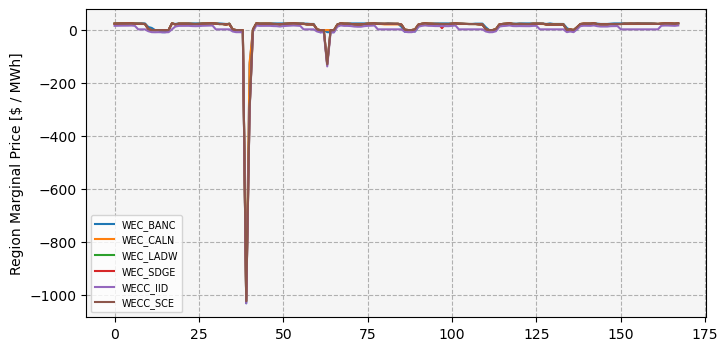

In [42]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, solution)

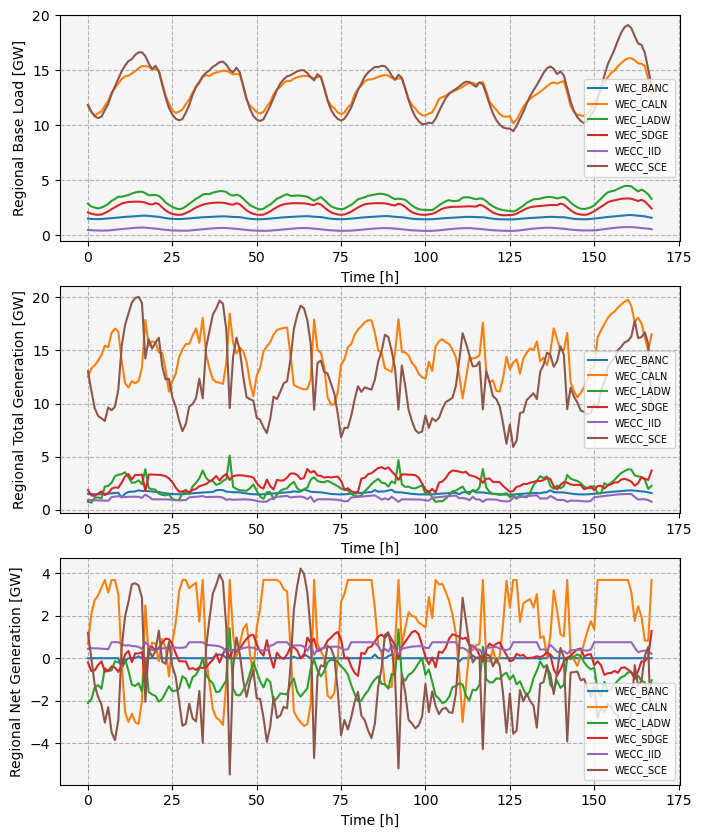

In [43]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], solution)
_ = vis.plot_total_generation(ax[1], solution)
_ = vis.plot_net_generation(ax[2], solution)

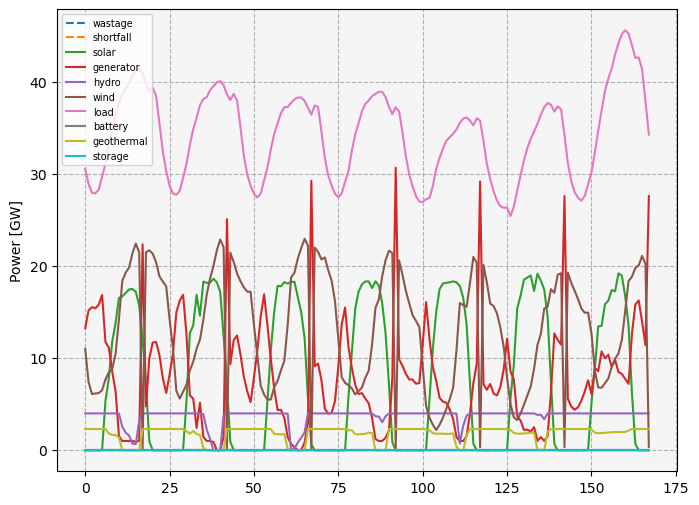

In [44]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, solution)

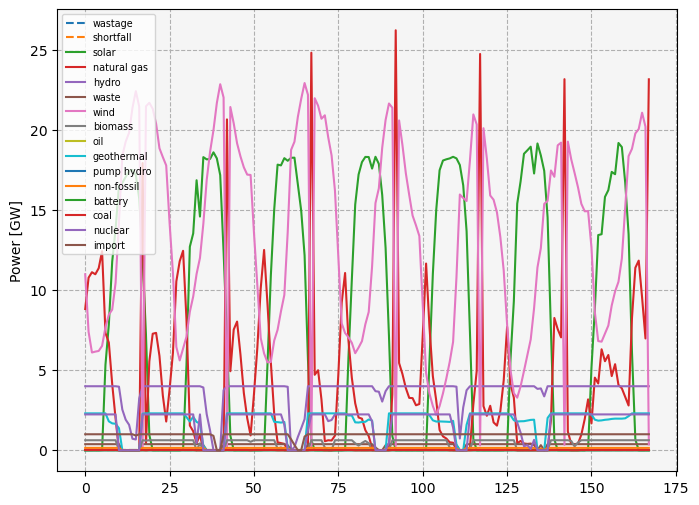

In [45]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, solution)

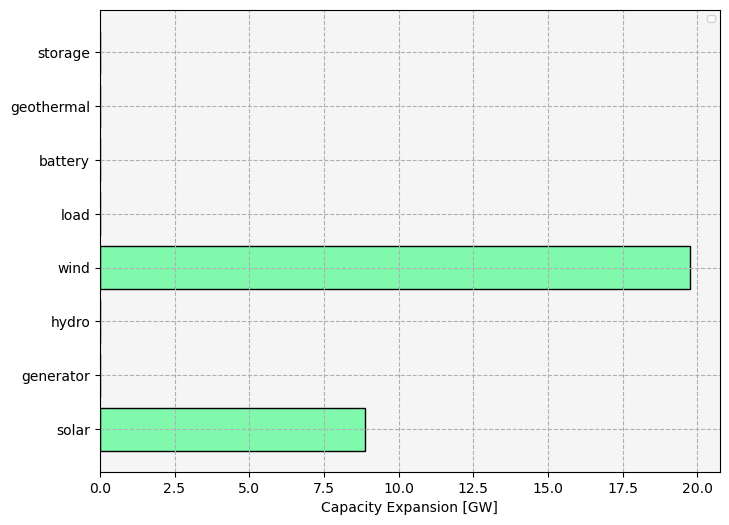

In [46]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)

Now, let's implement custom policies

In [30]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/California.json')

# for source, node in graph._node.items():
#     for handle, asset in node['assets'].items():

#         if asset['_class'] == 'Store':

#             asset['capex_cost'] = 0
#             print('a')

policies = {
    'california_ps':{
        '_class': 'Portfolio_Standard',
        'ratio': 0.85,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
        'exclusion_criteria': {
            0: "lambda a: not a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_ct': {
        '_class': 'Capacity_Target',
        'target': 70e9,
        'inclusion_criteria': {
            0: "lambda a: a.get('renewable', False)",
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
            3: "lambda a: a.get('jurisdiction', '') == 'CA'"
        },
    },
    'california_rm' : {
        '_class': 'Reserve_Margin',
        'margin': .1,
        'sign': -1,
        'demand_criteria': {
            2: "lambda a: a.get('type', '') == 'load'",
        },
        'supply_criteria': {
            1: "lambda a: a.get('_class', '') != 'Store'",
            2: "lambda a: a.get('type', '') != 'load'",
        },
    },
}

In [31]:
'''
Building from graph for 7 day run - 06/01:00:00:00 - 06/07:23:59:59
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'amortization_period': 31536000,
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(
    graph, policies)

'''
Building the model
'''

network.build()

'''
Printing model size report
'''

network.size()

Parameters Built: 0.17008757591247559
Variables Built: 0.08443021774291992
Constraints Built: 1.3077971935272217
Objective Built: 0.08580303192138672


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 51466, continuous_variables = 24199, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 24199), overall = Bunch(binary_variables = 0, constraints = 51466, continuous_variables = 24199, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 24199), warning = Bunch(unassociated_disjuncts = 0))

In [32]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
solution = network.solution

print(f'Objective Value: {pe.value(network.model.objective)}')

Problem Solved: 18.184223651885986
Results Collected: 0.715717077255249
Objective Value: 351787159.5711564


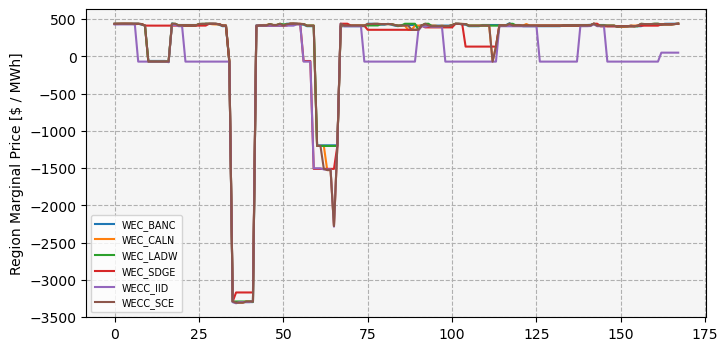

In [33]:
'''
Plotting LMPs
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 4))

_ = vis.plot_lmps(ax, solution)

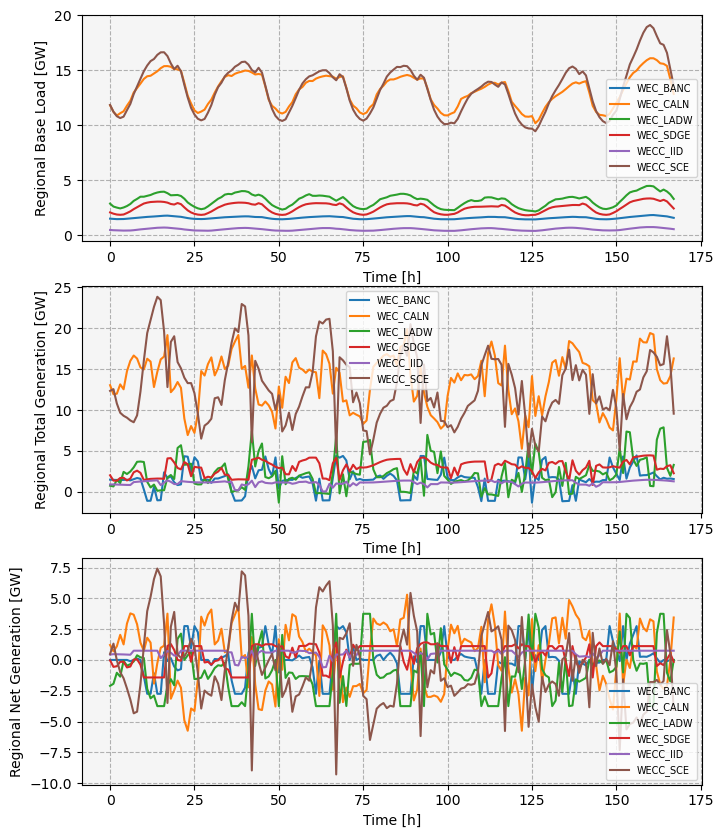

In [34]:
'''
Plotting Regional loads and generation
'''
deep_reload(vis)

fig, ax = plt.subplots(3, 1, figsize = (8, 10))

_ = vis.plot_base_loads(ax[0], solution)
_ = vis.plot_total_generation(ax[1], solution)
_ = vis.plot_net_generation(ax[2], solution)

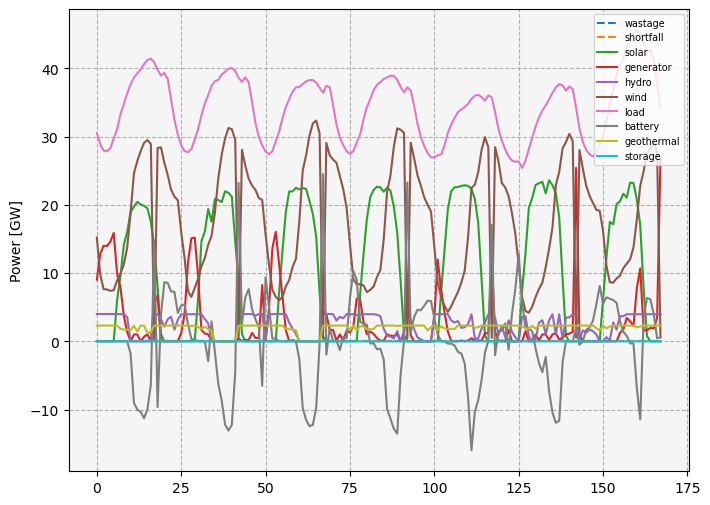

In [35]:
'''
Plotting generation by type
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_type(ax, solution)

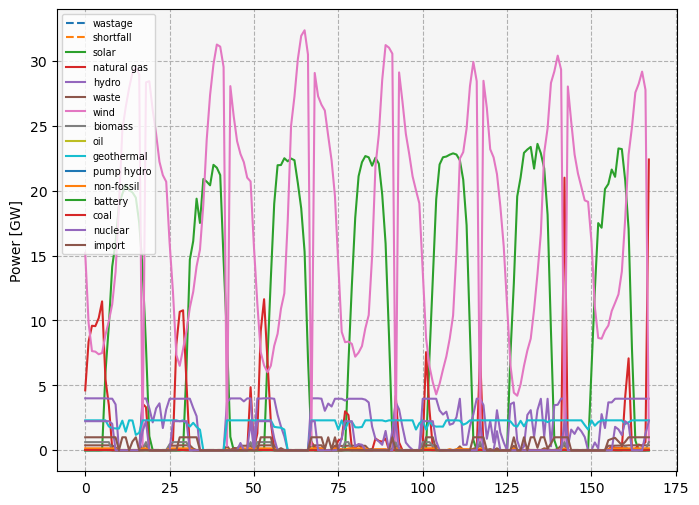

In [36]:
'''
Plotting generation by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_generation_by_fuel(ax, solution)

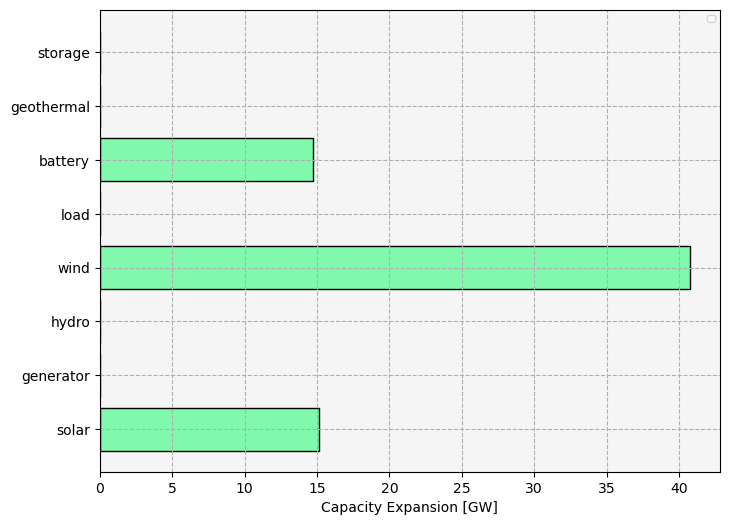

In [38]:
'''
Plotting capex by fuel
'''
deep_reload(vis)

fig, ax = plt.subplots(1, 1, figsize = (8, 6))

_ = vis.plot_capex_by_type(ax, solution)